# Event Study — Marijuana Legalization & Unemployment

Builds on `01_prelim.ipynb`. Working through this step by step.

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf


## What is `event_time`?

Take Colorado — `cohort_year = 2012` (the year voters approved recreational legalization). `event_time = year - cohort_year`.

In [47]:
panel = pd.read_csv('../data/processed/marijuana_panel.csv', parse_dates=['date'])

In [48]:
panel.head()

,date,ur,state,year,month,fips,recreational_vote_year,recreational_sales_year,cohort_year,is_treated,event_time
0,2005-01-01,7.1,AK,2005,1,2,2014.0,2016.0,2014.0,True,-9.0
1,2005-02-01,7.0,AK,2005,2,2,2014.0,2016.0,2014.0,True,-9.0
2,2005-03-01,6.9,AK,2005,3,2,2014.0,2016.0,2014.0,True,-9.0
3,2005-04-01,6.9,AK,2005,4,2,2014.0,2016.0,2014.0,True,-9.0
4,2005-05-01,6.8,AK,2005,5,2,2014.0,2016.0,2014.0,True,-9.0


## Collapse to annual

The BLS series is already seasonally adjusted (monthly averages are flat across the year), so there's no reason to pick one month. Take the mean `ur` per state-year instead of an arbitrary month snapshot.

In [49]:
group_cols = ['state', 'year']

annual_ur = panel.groupby(group_cols)['ur'].mean()
annual_ur = annual_ur.reset_index()

annual_meta = panel.groupby(group_cols)[['cohort_year', 'is_treated', 'event_time']].first()
annual_meta = annual_meta.reset_index()

annual_panel = annual_ur.merge(annual_meta, on=group_cols)

annual_panel.head()

,state,year,ur,cohort_year,is_treated,event_time
0,AK,2005,6.925000,2014.0,True,-9.0
1,AK,2006,6.616667,2014.0,True,-8.0
2,AK,2007,6.250000,2014.0,True,-7.0
3,AK,2008,6.508333,2014.0,True,-6.0
4,AK,2009,7.833333,2014.0,True,-5.0


In [50]:
is_co_row = annual_panel['state'] == 'CO'
co = annual_panel[is_co_row]

co[['year', 'cohort_year', 'event_time']]

,year,cohort_year,event_time
38,2005,2012.0,-7.0
39,2006,2012.0,-6.0
40,2007,2012.0,-5.0
41,2008,2012.0,-4.0
42,2009,2012.0,-3.0
43,2010,2012.0,-2.0
44,2011,2012.0,-1.0
45,2012,2012.0,0.0
46,2013,2012.0,1.0
47,2014,2012.0,2.0


In [51]:
co

,state,year,ur,cohort_year,is_treated,event_time
38,CO,2005,5.083333,2012.0,True,-7.0
39,CO,2006,4.250000,2012.0,True,-6.0
40,CO,2007,3.683333,2012.0,True,-5.0
41,CO,2008,4.841667,2012.0,True,-4.0
42,CO,2009,7.950000,2012.0,True,-3.0
43,CO,2010,9.141667,2012.0,True,-2.0
44,CO,2011,8.691667,2012.0,True,-1.0
45,CO,2012,7.991667,2012.0,True,0.0
46,CO,2013,6.725000,2012.0,True,1.0
47,CO,2014,4.950000,2012.0,True,2.0


In [52]:
formula = 'ur ~ event_time' 
model = smf.ols(formula, data=co).fit() 

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     ur   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     2.866
Date:                Fri, 17 Jul 2026   Prob (F-statistic):              0.109
Time:                        09:49:30   Log-Likelihood:                -39.592
No. Observations:                  19   AIC:                             83.18
Df Residuals:                      17   BIC:                             85.07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.4011      0.502     10.759      0.000       4.342       6.460
event_time    -0.1457      0.086     -1.693      0.109      -0.327       0.036
==============================================================================
Omnibus:                        5.204   Durbin-Watson:                   0.639
Prob(Omnibus):                  0.074   Jarque-Bera (JB):                2.172
Skew:                           0.501   Prob(JB):                        0.338
Kurtosis:                       1.681   Cond. No.                         6.23
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# integrate a control region

In [53]:
study_states = ['ID', 'KS', 'NE', 'UT', 'WY', 'CO']
is_study_state = annual_panel['state'].isin(study_states)

study_period = annual_panel[is_study_state]

In [54]:
study_period.head()

,state,year,ur,cohort_year,is_treated,event_time
38,CO,2005,5.083333,2012.0,True,-7.0
39,CO,2006,4.250000,2012.0,True,-6.0
40,CO,2007,3.683333,2012.0,True,-5.0
41,CO,2008,4.841667,2012.0,True,-4.0
42,CO,2009,7.950000,2012.0,True,-3.0


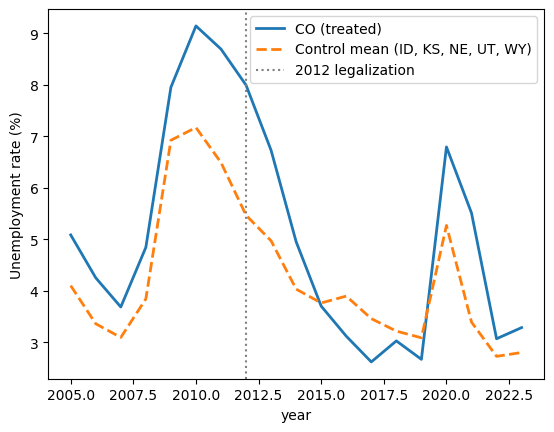

In [55]:
is_control = study_period['state'] != 'CO'
control_rows = study_period[is_control]
control_mean = control_rows.groupby('year')['ur'].mean()

is_co = study_period['state'] == 'CO'
co_rows = study_period[is_co]
co_series = co_rows.set_index('year')['ur']

fig, ax = plt.subplots()

co_series.plot(ax=ax, label='CO (treated)', linewidth=2)
control_mean.plot(ax=ax, label='Control mean (ID, KS, NE, UT, WY)', linewidth=2, linestyle='--')

legalization_year = 2012
ax.axvline(legalization_year, color='gray', linestyle=':', label='2012 legalization')

ax.set_ylabel('Unemployment rate (%)')
ax.legend()

plt.show()

## Pool all treated states

Same idea as the CO-vs-control picture, but now averaged across all 8 treated states, plotted on the `event_time` axis instead of calendar year. This is what lets a single calendar shock (like COVID) land at different points for different cohorts instead of contaminating one spot.

In [56]:
is_treated_group = annual_panel['is_treated'] == True
treated_rows = annual_panel[is_treated_group]

event_time_mean = treated_rows.groupby('event_time')['ur'].mean()
event_time_count = treated_rows.groupby('event_time')['ur'].count()

event_time_mean

event_time
-11.0    4.818750
-10.0    4.614583
-9.0     5.398611
-8.0     6.152778
-7.0     7.630208
-6.0     8.009375
-5.0     8.310417
-4.0     8.053125
-3.0     8.298958
-2.0     7.759375
-1.0     6.884375
 0.0     6.121875
 1.0     5.267708
 2.0     4.694792
 3.0     4.245833
 4.0     7.091667
 5.0     5.089583
 6.0     4.908333
 7.0     4.292708
 8.0     5.950000
 9.0     4.685417
 10.0    3.554167
 11.0    3.750000
Name: ur, dtype: float64

In [57]:
event_time_count

event_time
-11.0    4
-10.0    4
-9.0     6
-8.0     6
-7.0     8
-6.0     8
-5.0     8
-4.0     8
-3.0     8
-2.0     8
-1.0     8
 0.0     8
 1.0     8
 2.0     8
 3.0     8
 4.0     8
 5.0     8
 6.0     8
 7.0     8
 8.0     4
 9.0     4
 10.0    2
 11.0    2
Name: ur, dtype: int64

All 8 treated states cover `event_time` -7 through +7. Outside that window the count drops (only CO/WA reach +10/+11, only the latest cohorts reach -10/-11) — so the tails of the plot below are less reliable, averaged over fewer states.

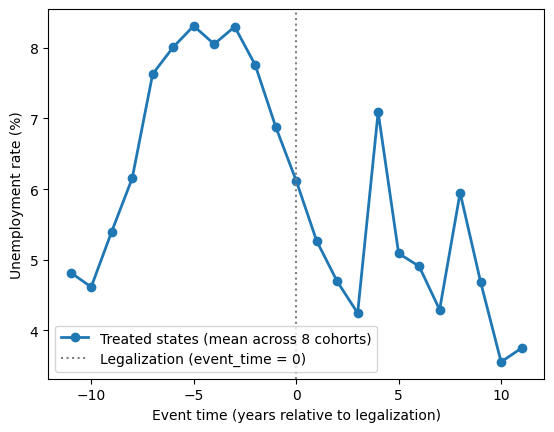

In [58]:
fig, ax = plt.subplots()

event_time_mean.plot(ax=ax, label='Treated states (mean across 8 cohorts)', linewidth=2, marker='o')

reference_event_time = 0
ax.axvline(reference_event_time, color='gray', linestyle=':', label='Legalization (event_time = 0)')

ax.set_xlabel('Event time (years relative to legalization)')
ax.set_ylabel('Unemployment rate (%)')
ax.legend()

plt.show()

## Treated-minus-control gap by event_time

Controls don't have their own `event_time` (never legalized), so we can't just group them the same way. Instead: for every treated state-year, look up the control-group mean `ur` in that *same calendar year*, and subtract it. That difference is a same-year, macro-adjusted gap — averaging it across all treated states by `event_time` should cancel out shared shocks like the 2009 recession or COVID, leaving something closer to an actual treatment-effect shape.

In [ ]:
is_control_group = annual_panel['is_treated'] == False
control_rows_all = annual_panel[is_control_group]

control_mean_by_year = control_rows_all.groupby('year')['ur'].mean()
control_mean_by_year.name = 'control_mean'

treated_rows_with_control = treated_rows.merge(control_mean_by_year, on='year')
treated_rows_with_control['gap'] = treated_rows_with_control['ur'] - treated_rows_with_control['control_mean']

treated_rows_with_control[['state', 'year', 'event_time', 'ur', 'control_mean', 'gap']].head()

In [ ]:
gap_mean_by_event_time = treated_rows_with_control.groupby('event_time')['gap'].mean()
gap_count_by_event_time = treated_rows_with_control.groupby('event_time')['gap'].count()

gap_mean_by_event_time

In [ ]:
fig, ax = plt.subplots()

gap_mean_by_event_time.plot(ax=ax, label='Treated minus control (mean gap)', linewidth=2, marker='o')

zero_gap = 0
ax.axhline(zero_gap, color='black', linewidth=1)

reference_event_time = 0
ax.axvline(reference_event_time, color='gray', linestyle=':', label='Legalization (event_time = 0)')

ax.set_xlabel('Event time (years relative to legalization)')
ax.set_ylabel('Unemployment rate gap, treated minus control (pp)')
ax.legend()

plt.show()